# Explore Bemify simulation results

Hits `https://api.bemify.no/simulate` once, caches the JSON result to `simulation_result.json`, then loads it for exploration. Delete the cache file (or set `FORCE_REFRESH = True`) to re-run the simulation.

Requirements: `pip install requests pandas matplotlib truststore`

In [ ]:
import json
import os
import time
from pathlib import Path

import truststore

truststore.inject_into_ssl()  # use Windows cert store (fixes local SSL interception)

import pandas as pd
import requests

API_URL = "https://api.bemify.no"
API_TOKEN = ""
TOKEN = os.environ.get("BEMIFY_TOKEN", API_TOKEN)
MODEL_FILE = "building.sxi"
SIMULERINGSTYPE = "aarssimulering"  # aarssimulering | energimerke | tek17
KLIMASTED = "Oslo"               # ignored when SIMULERINGSTYPE == 'tek17'

CACHE_FILE = Path(f"simulation_result_{SIMULERINGSTYPE}.json")
FORCE_REFRESH = False

headers = {"Authorization": f"Bearer {TOKEN}"}

In [9]:
def run_simulation():
    data = {"simuleringstype": SIMULERINGSTYPE}
    if SIMULERINGSTYPE != "tek17":
        data["klimasted"] = KLIMASTED

    with open(MODEL_FILE, "rb") as model:
        resp = requests.post(
            f"{API_URL}/simulate",
            headers=headers,
            files={"model": model},
            data=data,
        )
    resp.raise_for_status()
    job_id = resp.json()["jobId"]
    print(f"Job: {job_id}")

    while True:
        status = requests.get(f"{API_URL}/job/{job_id}", headers=headers).json()
        if status["status"] in ("completed", "error"):
            break
        print(f"  {status['status']}...")
        time.sleep(2)

    if status["status"] == "error":
        raise RuntimeError(status.get("error", "unknown error"))
    return status["result"]


if CACHE_FILE.exists() and not FORCE_REFRESH:
    result = json.loads(CACHE_FILE.read_text(encoding="utf-8"))
    print(f"Loaded cached result from {CACHE_FILE}")
else:
    result = run_simulation()
    CACHE_FILE.write_text(json.dumps(result, indent=2, ensure_ascii=False), encoding="utf-8")
    print(f"Cached result to {CACHE_FILE}")

print("Top-level keys:", list(result.keys()))

Job: job_1785796298795_5
  running...
  running...
Cached result to simulation_result_aarssimulering.json
Top-level keys: ['outputMode', 'beregningspunkter', 'sentralAndelSone', 'distribusjonsOgAkkumuleringstap', 'quarterlyEffektPerZone', 'quarterlyTemperaturPerZone', 'monthlyThermalPerZone', 'monthlyTemperaturesPerZone', 'ventilasjonStatsPerZone', 'gjenvinnerStatsPerZone', 'energyPerPostPerZone', 'monthlyEnergyPerPostPerZone', 'zones', 'varmetapstallPerSone', 'solcelleProduction', 'vindturbinProduction', 'warnings', 'kildeSPF', 'kildeOutput', 'metadata', 'energimerke']


## Zones

In [10]:
zones_df = pd.DataFrame(result.get("zones", []))
print(f"Total area: {zones_df['area'].sum():.1f} m2")
zones_df

Total area: 900.0 m2


,id,area,navn
0,sonewQCOwtP42IswcmhETswL6,900,Sone 1


## Calculation points (NS 3031)

`netto` (A) net demand -> `brutto` (B) gross demand -> `tilfort` (C) supplied -> `levert` (D) delivered.

In [11]:
bp = result["beregningspunkter"]
for name, point in bp.items():
    print(f"\n=== {name} ===")
    print("  keys:", list(point.keys()))


=== netto ===
  keys: ['energyResults', 'energyTotal', 'powerDemand', 'peakTimestamps', 'totalPeakPower']

=== brutto ===
  keys: ['energyResults', 'energyTotal', 'powerDemand', 'peakTimestamps', 'totalPeakPower']

=== tilfort ===
  keys: ['tilfortEnergi', 'tilfortEnergiTotal', 'levertEffekt', 'levertEffektTimestamps', 'levertEffektTotal']

=== levert ===
  keys: ['levertEnergi', 'total', 'elektriskBudsjett', 'klimafordeling', 'oppvarmingOutput_kWh', 'kjoelingOutput_kWh', 'apentIldstedBio_kWh', 'monthlyLevertPerKilde', 'monthlyMakseffektPerKilde']

=== nzebLevert ===
  keys: ['levertEnergi', 'total', 'elektriskBudsjett', 'klimafordeling', 'oppvarmingOutput_kWh', 'kjoelingOutput_kWh', 'apentIldstedBio_kWh', 'monthlyLevertPerKilde', 'monthlyMakseffektPerKilde']


In [12]:
# Build a long-form frame of annual totals across all calculation points.
# Each point stores its totals under a DIFFERENT key:
#   netto/brutto -> energyResults (keyed by energy post)
#   tilfort      -> tilfortEnergi (keyed by energy post)
#   levert       -> levertEnergi  (keyed by energy CARRIER, e.g. "1 Levert elektrisitet")
# The keyspaces differ (post vs carrier), but column totals are still comparable.
TOTALS_FIELD = {
    "netto": "energyResults",
    "brutto": "energyResults",
    "tilfort": "tilfortEnergi",
    "levert": "levertEnergi",
}
rows = []
for point_name, field in TOTALS_FIELD.items():
    point = bp.get(point_name, {})
    er = point.get(field) or {}
    for post, value in er.items():
        if isinstance(value, (int, float)):
            rows.append({"beregningspunkt": point_name, "post": post, "kWh": value})

energy_df = pd.DataFrame(rows)
energy_wide = energy_df.pivot(index="post", columns="beregningspunkt", values="kWh").fillna(0)
energy_wide.loc["TOTAL"] = energy_wide.sum()
energy_wide.round(0)

beregningspunkt,brutto,levert,netto,tilfort
post,,,,
1 Levert elektrisitet,0.0,87657.0,0.0,0.0
1a Romoppvarming,28205.0,0.0,28205.0,28205.0
1b Ventilasjonsvarme,2750.0,0.0,2750.0,2750.0
2 Varmtvann,25721.0,0.0,22548.0,25721.0
2a Fast biobrensel,0.0,0.0,0.0,0.0
2b Flytende biobrensel,0.0,0.0,0.0,0.0
2c Biobrensel i gassform,0.0,0.0,0.0,0.0
2d Fast fossilt brensel,0.0,0.0,0.0,0.0
2e Flytende fossilt brensel,0.0,0.0,0.0,0.0


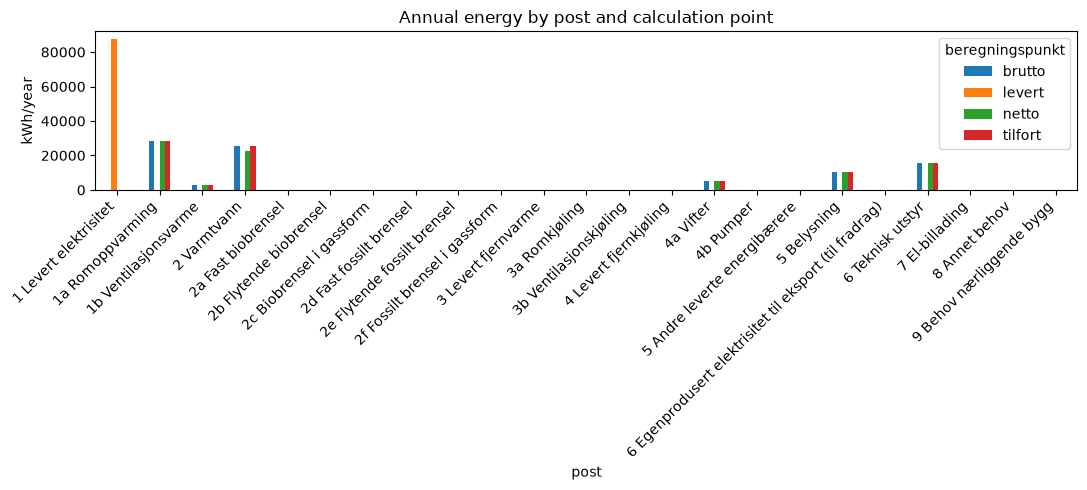

In [13]:
import matplotlib.pyplot as plt

plot_df = energy_wide.drop("TOTAL", errors="ignore")
ax = plot_df.plot(kind="bar", figsize=(11, 5))
ax.set_ylabel("kWh/year")
ax.set_title("Annual energy by post and calculation point")
ax.legend(title="beregningspunkt")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

## Delivered energy breakdown (`levert`)

In [14]:
levert = bp["levert"]
# Show all scalar fields at a glance, and any nested dicts (e.g. levertEnergi per carrier).
# Dicts are flattened one level so nested structures like `klimafordeling` still render.
for key, val in levert.items():
    if isinstance(val, dict):
        flat = {}
        for k, v in val.items():
            if isinstance(v, dict):
                for sk, sv in v.items():
                    if isinstance(sv, (int, float)):
                        flat[f"{k}.{sk}"] = sv
            elif isinstance(v, (int, float)):
                flat[k] = v
        if flat:
            print(f"\n{key}:")
            print(pd.Series(flat).round(1).to_string())
    elif isinstance(val, (int, float)):
        print(f"{key}: {val:.1f}")


levertEnergi:
1 Levert elektrisitet                                     87657.1
2a Fast biobrensel                                            0.0
2b Flytende biobrensel                                        0.0
2c Biobrensel i gassform                                      0.0
2d Fast fossilt brensel                                       0.0
2e Flytende fossilt brensel                                   0.0
2f Fossilt brensel i gassform                                 0.0
3 Levert fjernvarme                                           0.0
4 Levert fjernkjøling                                         0.0
5 Andre leverte energibærere                                  0.0
6 Egenprodusert elektrisitet til eksport (til fradrag)        0.0
total: 87657.1

elektriskBudsjett:
elSpesifikk     30980.8
elOppvarming    30955.1
elVarmtvann     25721.1
elKjøling           0.0
egenforbruk         0.0
eksport             0.0
sum_1_5         87657.1
sum_1_6         87657.1

klimafordeling:
klimaavhengig.1

## Energy label (`energimerke`)

Only present when `SIMULERINGSTYPE = 'energimerke'`, and the project has a valid kommune + building category.

In [ ]:
em = result.get("energimerke")
if em is None:
    print("No energimerke in this result. Re-run with SIMULERINGSTYPE = 'energimerke'.")
else:
    summary = {k: v for k, v in em.items() if k != "items"}
    print(pd.Series(summary).to_string())
    print()
    display(pd.DataFrame(em["items"]))

## TEK17 validation

Only present when `SIMULERINGSTYPE = 'tek17'`.

In [16]:
tek = result.get("tek17")
if tek is None:
    print("No tek17 block in this result. Re-run with SIMULERINGSTYPE = 'tek17'.")
else:
    print(f"erSamsvarsende: {tek['erSamsvarsende']}")
    print(f"Oppsummering:   {tek['oppsummering']}")

    er = tek["energiramme"]
    print(f"\nEnergiramme ({er['bygningskategori']}):")
    print(f"  Beregnet:  {er['totalBeregnet']:.1f} kWh/m2")
    print(f"  Krav:      {er['forskriftskrav']:.1f} kWh/m2")
    print(f"  Status:    {er['status']}")
    display(pd.DataFrame(er["poster"]))

No tek17 block in this result. Re-run with SIMULERINGSTYPE = 'tek17'.


In [17]:
if tek is not None:
    for section in ("minstekrav", "luftmengder"):
        print(f"\n{section} ({tek[section]['samletStatus']}):")
        display(pd.DataFrame(tek[section]["rader"]))

## Raw inspection

Handy when the helpers above don't show a field you're after.

In [18]:
def shape(obj, depth=0, max_depth=3):
    indent = "  " * depth
    if isinstance(obj, dict):
        for k, v in obj.items():
            if isinstance(v, dict):
                print(f"{indent}{k}: dict ({len(v)} keys)")
                if depth < max_depth:
                    shape(v, depth + 1, max_depth)
            elif isinstance(v, list):
                sample = type(v[0]).__name__ if v else "empty"
                print(f"{indent}{k}: list[{sample}] (len={len(v)})")
            else:
                print(f"{indent}{k}: {type(v).__name__} = {v!r:.80}")

shape(result)

outputMode: str = 'aggregated'
beregningspunkter: dict (5 keys)
  netto: dict (5 keys)
    energyResults: dict (12 keys)
      1a Romoppvarming: float = 28204.64
      1b Ventilasjonsvarme: float = 2750.5
      2 Varmtvann: float = 22548.24
      3a Romkjøling: int = 0
      3b Ventilasjonskjøling: int = 0
      4a Vifter: float = 4927.5
      4b Pumper: int = 0
      5 Belysning: float = 10262.34
      6 Teknisk utstyr: int = 15791
      7 El-billading: int = 0
      8 Annet behov: int = 0
      9 Behov nærliggende bygg: int = 0
    energyTotal: float = 84484.21
    powerDemand: dict (12 keys)
      1a Romoppvarming: int = 25219
      1b Ventilasjonsvarme: int = 2509
      2 Varmtvann: int = 6489
      3a Romkjøling: int = 0
      3b Ventilasjonskjøling: int = 0
      4a Vifter: int = 563
      4b Pumper: int = 0
      5 Belysning: int = 1539
      6 Teknisk utstyr: int = 3897
      8 Annet behov: int = 0
      7 El-billading: int = 0
      9 Behov nærliggende bygg: int = 0
    peakTi

## Energy flow (A → B → C → D)

The NS 3031 points measure energy at different boundaries: `netto` (building need) →
`brutto` (+ system losses, e.g. distribution / plant heat loss) → `tilfort` (energy
supplied to the sources) → `levert` (what the meter measures, per carrier).

Note: this is **not** a monotonic loss chain. `tilfort` (C) can be *lower* than `brutto`
(B) when heat pumps (COP > 1) or solar thermal cover part of the demand — the sources
deliver more thermal energy than the electricity/fuel supplied to them. So a negative
"step loss" from B→C is expected for heat-pump buildings, and does not indicate an error.

             kWh  step_loss_kWh  cum_loss_%
netto    84484.0            0.0         0.0
brutto   87657.0         3173.0         4.0
tilfort  87657.0            0.0         4.0
levert   87657.0           -0.0         4.0


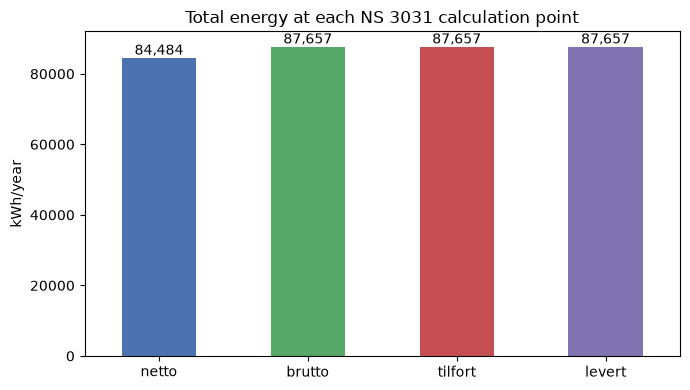

In [19]:
ORDER = ["netto", "brutto", "tilfort", "levert"]
totals = {name: energy_wide[name].drop("TOTAL", errors="ignore").sum()
          for name in ORDER if name in energy_wide.columns}
flow = pd.DataFrame({"kWh": totals})
flow["step_loss_kWh"] = flow["kWh"].diff().fillna(0).round(0)
flow["cum_loss_%"] = ((flow["kWh"] - flow["kWh"].iloc[0]) / flow["kWh"].iloc[0] * 100).round(1)
print(flow.round(0).to_string())

ax = flow["kWh"].plot(kind="bar", figsize=(7, 4), color=["#4c72b0", "#55a868", "#c44e52", "#8172b2"])
ax.set_ylabel("kWh/year")
ax.set_title("Total energy at each NS 3031 calculation point")
for i, v in enumerate(flow["kWh"]):
    ax.text(i, v, f"{v:,.0f}", ha="center", va="bottom")
plt.xticks(rotation=0)
plt.tight_layout()

## Specific energy intensity (kWh/m²·year)

Absolute kWh depends on building size — normalising by heated floor area gives the number you'd compare across buildings or against TEK17 / energimerke thresholds.